In [1]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import tools.ai_token as tk
import tools.ai_attention_decoder as att
import os
import random


In [ ]:
# Configuration
base_folder = "data/train/wiki_fr_test"
output_file = "data/corpus_tokenizer_15mb.txt"
num_files_to_merge = 15

# 1. Récupérer tous les fichiers de tous les répertoires
all_files = []

# Parcourir tous les répertoires (AA à CN)
for subdir in os.listdir(base_folder):
    subdir_path = os.path.join(base_folder, subdir)
    
    # Vérifier que c'est bien un répertoire
    if os.path.isdir(subdir_path):
        # Récupérer tous les fichiers .txt du répertoire
        files_in_subdir = [f for f in os.listdir(subdir_path)]
        
        # Ajouter le chemin complet à la liste
        for fname in files_in_subdir:
            full_path = os.path.join(subdir_path, fname)
            all_files.append(full_path)

print(f"Total fichiers trouvés : {len(all_files)}")

# 2. Sélection aléatoire
if len(all_files) > num_files_to_merge:
    selected_files = random.sample(all_files, num_files_to_merge)
else:
    selected_files = all_files
    print(f"Attention : Seulement {len(selected_files)} fichiers disponibles")

print(f"Fusion de {len(selected_files)} fichiers...")

# 3. Fusion
total_size = 0
with open(output_file, 'w', encoding='utf-8') as outfile:
    for file_path in selected_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as infile:
                content = infile.read()
                outfile.write(content + "\n")
                total_size += len(content.encode('utf-8'))
                print(f"✓ Ajouté : {file_path}")
        except Exception as e:
            print(f"✗ Erreur avec {file_path} : {e}")

print(f"\nFichier créé : {output_file}")
print(f"Taille approximative : {total_size / (1024*1024):.2f} MB")

In [ ]:
fileName = 'data/corpus_tokenizer_15mb.txt'
token_ = tk.BPETokenizer(fileName=fileName)
print(token_.token[:100])

In [ ]:
token_.addToken = 30000
token_.train(False)
print(token_.ids[:100])

In [ ]:
prompt = "ceci est un essai d'encodage pour voir si tout fonctionne !"
ids = token_.encode(prompt)
print(ids[:100])
print(token_.ids[:100])
print(token_.display_token())
print(token_.display_token(token_.ids[:100]))
print(len(token_.vocab))

In [ ]:
token_.save_vocab('data/ep_vocab_full.json')
token_.save_merges('data/ep_merges_full.json')

In [2]:
token_ = tk.BPETokenizer()
token_.load_merges('data/ep_merges_full.json')

vous devrez soit lire un fichier soit envoyer un texte pour lancer le tokenizer


In [3]:
print(len(token_.vocab))

30256


# Entrainement du model

In [ ]:
token_.display_token(token_.ids)

# Verif

In [ ]:
print(token.ids[:100])

In [ ]:
print(ids1[:100])

In [ ]:
a = token.decode(token.get_array(ids2))
b = token.decode(ids3)
c = token.decode(ids1.tolist())

In [ ]:
print(a[:100])
print(a==b)
print(a==token.text_cleaned)
print(b==token.text_cleaned)

In [ ]:
token.addToken = 400
token.train(verbose=False)

In [ ]:
token.save_merges('data/merges.json')

In [ ]:
print(token._get_max_stats())
print(token._get_max_stats_numpy())

In [ ]:
e = token.encode_np(token.text_cleaned)

In [ ]:
c = (ids[ids != -1]).tolist()

In [ ]:
print(e[-100:])
print(c[-100:])
print(len(c), len(e))
print(c==e)

In [ ]:
print(token.merges)

In [ ]:
token._vocab()

In [ ]:
print(e[:100])
token.display_token(e[:1000])

In [ ]:
text_encode_array = token.get_array(token.ids)
text = token.decode()
print(token.ids[:100])
print(text_encode_array[:100])
print(text[:100])


In [ ]:
print(token.ids[100:200])  # Affiche les 5 premiers échantillons tokenisés
print(token.token[100:200])  # Affiche les 5 premiers échantillons tokenisés en bytes
print(token.vocab)

# Load un vocab

In [ ]:
token.load_vocab(filepath='data/tokenizer.json')

In [ ]:
ids = token.encode_np(token.text_cleaned)

In [ ]:
token.display_token()

# Test decoder

In [4]:
import tools.ai_attention_decoder as at

### Historiques
 * v0 : 60,28s
 * v1 (head et multihead fusionnées) : 29,51s
 * v2 (block et feedforward optimisés et utiliosation de GELU vs ReLU) : 28,40s

In [ ]:
config = { 'n_embd': 128,
            'num_heads': 4,
            'n_layers': 4,
            'block_size': 128,
            'dropout': 0.1,      
        }
parameters = {
    'batch_size': 32,
    'max_iters': 2000,
    'eval_interval': 500,
    'eval_iters': 200,
    'learning_rate': 1e-4
}

In [ ]:
decoder = att.Model(token_.ids, token_, **config, **parameters, fileout='data/test_train_1.pth')
decoder.get_model_size()

In [ ]:
decoder.train()
decoder.plot_losses()


In [ ]:
prompt = "Ceci est l'histoire d'un ROI, grand et beau qui raconte sa dernière bataille"
ids_p = token.encode(prompt)
print(ids_p)

In [ ]:
decoder.genere(new_token=200)

In [ ]:
decoder.genere(prompt, 100)

In [ ]:
len(decoder.token_.vocab)

# Chargement d'un nouveau VOCAB

In [5]:
print(token_.encode('coucou'))


[99, 7225, 284]


In [6]:
import tools.ai_gpt_ep as gpt

In [11]:
# --- EXEMPLE D'UTILISATION ---

# Configuration du modèle (Architecture fixe)
model_config = {
    'n_embd': 384, 'num_heads': 6, 'n_layers': 6, 
    'block_size': 256, 'dropout': 0.1
}

# Paramètres d'entraînement (Modifiables à chaque session !)
train_params = {
    'batch_size': 16,
    'grad_accum_steps': 4, # Simule batch 64
    'learning_rate': 6e-4,  # Vitesse standard
    'min_lr' : 6e-5, # Généralement 10% du LR max
    'warmup_iters' : 500,
    'lr_decay_iters' : 50000 # Doit correspondre à la fin prévue de votre entraînement
}

trainer = gpt.ContinuousTrainer(
    model_class=gpt.GPTLanguageModel, # Votre classe définie plus haut
    tokenizer=token_,              # Votre objet tokenizer
    config=model_config,
    train_params=train_params,
    data_root="data/train/wiki_fr_test",
    log_file="model/my_wiky_log.txt",
    ckpt_path="model/my_wiki.pth",
    history_path='model/my_wiky_history.json'
)

# Lance l'entraînement sur 20 fichiers puis s'arrête
trainer.run_training_loop(max_files_session=8)

🚀 Device: mps
📥 Chargement du checkpoint : model/my_wiki.pth
✅ Modèle restauré. (Fichiers déjà traités : 20)
📊 Statut : 20 terminés, 6498 restants.
▶️ Démarrage de la session sur 8 fichiers...

[1/8] Loss: 3.6915 | Fichier: BR/wiki_44
💾 Sauvegarde du checkpoint...
[2/8] Loss: 4.0021 | Fichier: BC/wiki_53
💾 Sauvegarde du checkpoint...
[3/8] Loss: 3.9118 | Fichier: BU/wiki_20
💾 Sauvegarde du checkpoint...
[4/8] Loss: 3.8864 | Fichier: BL/wiki_13
💾 Sauvegarde du checkpoint...
[5/8] Loss: 4.0087 | Fichier: AU/wiki_40
💾 Sauvegarde du checkpoint...
[6/8] Loss: 3.2687 | Fichier: AG/wiki_32
💾 Sauvegarde du checkpoint...
[7/8] Loss: 2.4813 | Fichier: AO/wiki_38
💾 Sauvegarde du checkpoint...
[8/8] Loss: 3.6806 | Fichier: BK/wiki_45
💾 Sauvegarde du checkpoint...

✅ Session terminée. Vous pouvez relancer le script pour la suite.


In [ ]:
# Lance l'entraînement sur 20 fichiers puis s'arrête
trainer.run_training_loop(max_files_session=20)

In [ ]:
# Nouvelle session plus fine
train_params = {
    'batch_size': 8,
    'grad_accum_steps': 4,
    'learning_rate': 1e-5  # <--- On a réduit le LR pour affiner
}
# Le reste est identique, le Trainer va charger les anciens poids 
# mais utiliser le NOUVEL optimiser avec le LR de 1e-5.
trainer = gpt.ContinuousTrainer(
    model_class=gpt.GPTLanguageModel, # Votre classe définie plus haut
    tokenizer=token_,              # Votre objet tokenizer
    config=model_config,
    train_params=train_params,
    data_root="data/train/wiki_fr_test",
    ckpt_path="mon_modele_wiki.pth"
)
trainer.run_training_loop(max_files_session=10)

In [15]:
train_model = gpt.GenerateGPT(tokinizer=token_, ckpt_path="model/my_wiki.pth")
train_model.load_for_inference()

Loading model/my_wiki.pth on mps...


In [13]:
prompt = "qui est Guy de Saint Baube"

In [16]:
out_ = train_model.generate_text(prompt=prompt, max_new_tokens=100,temperature=0.8)
print("-" * 40)
print(f"🤖 IA : {out_}")
print("-" * 40)

----------------------------------------
🤖 IA : qui est Guy de Saint Baubeh, représentant la justice d’Hôpital de Lens-Lyschor (district de Columbia), l’époque de 1995. Le charbonnage de Cossikayt est implanté en France dans les années 1980 par le charbonnage du Gaïa Fype Park de Benozkounov en 1993, il avait naissance un groupe de ses neuf incluent 250 entreprises. 
Transports.
La concession de Crippen a été construite au début des
----------------------------------------


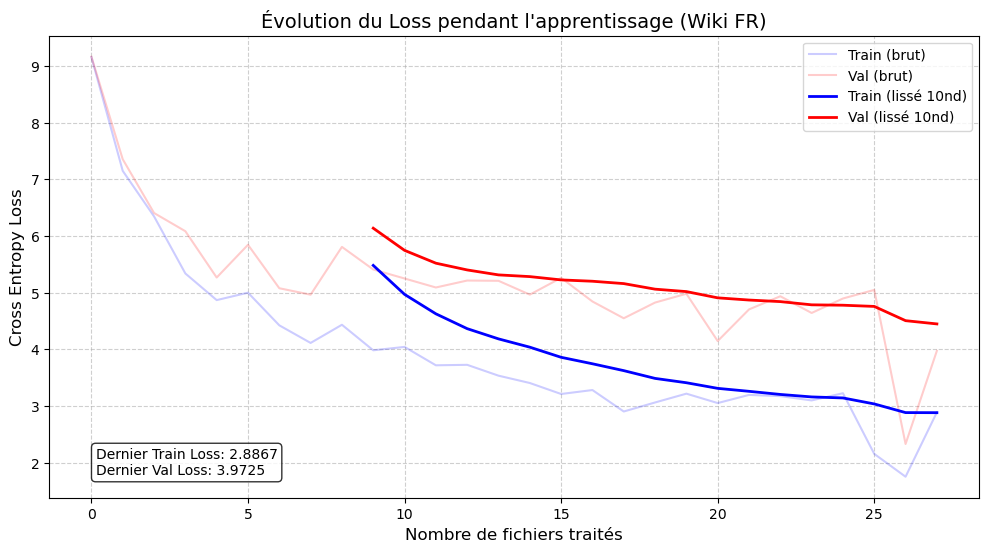

In [12]:
visualizer = gpt.TrainingVisualizer('model/my_wiky_history.json')
visualizer.plot_metrics(window_size=10) # Lissage sur 10 fichiers